# Prédire les crises d'épilepsie à partir de l'ECG
**Projet DESU Data Science - Alina Titova**

**Tuteur : Nicolas Rochet**

Dataset : [SeizeIT2 — OpenNeuro ds005873](https://openneuro.org/datasets/ds005873/versions/1.1.0)

In [22]:
# Tout d'abord on import les librairies nécessaires

import pandas as pd
import numpy as np
import mne
import sklearn 
import matplotlib.pyplot as plt
import os 
import glob
import random
import openpyxl as px 

# Dossier qui contient tous les patients (sub-001, sub-002, etc.)
DOSSIER_DATA = r"C:\Users\Alina\Desktop\AMU\DESU Data science\Projet\Data"

## 1.Fonctons

In [19]:
# Ici on définit quelques fonctions pour manipuler les fichiers EEG et ECG des patients.
# ECG est le coeur pour les prédictions, mais il est stocké dans un dossier séparé du dossier EEG. On va donc relier les deux.

# Cette fonction permet de trouver  le dossier spécifique à l'autre niveau.
def dossier_eeg(patient):
    """Donne le chemin du dossier eeg d'un patient. Exemple : dossier_eeg("sub-100")"""
    return os.path.join(DOSSIER_DATA, patient, "ses-01", "eeg")

# Cette fonction permet de lister toutes les crises d'un patient. Car les crises sont listées dans les fichiers *_events.tsv du dossier eeg.
def liste_crises(patient):
    """Lit tous les fichiers .tsv du patient et renvoie un tableau de TOUTES ses crises."""
    fichiers_tsv = sorted(glob.glob(os.path.join(dossier_eeg(patient), "*_events.tsv"))) 
    # La fonction glob.glob() permet de lister tous les fichiers qui correspondent à un motif donné. Ici, on cherche tous les fichiers qui se terminent par "_events.tsv" dans le dossier eeg du patient.

    toutes_les_crises = []
    for fichier in fichiers_tsv:
        tableau = pd.read_csv(fichier, sep="\t")
        crises = tableau[tableau["eventType"].str.startswith("sz", na=False)]
        for _, ligne in crises.iterrows():
            toutes_les_crises.append({
                "fichier_tsv": fichier,
                "debut": ligne["onset"],
                "duree": ligne["duration"],
                "type": ligne["eventType"],
            })
    return pd.DataFrame(toutes_les_crises)


# Après avoir trouvé les crises, on va chercher le fichier ECG correspondant à la même run. Car le fichier ECG est stocké dans un dossier séparé du dossier EEG.
def fichier_ecg(fichier_tsv):
    """À partir du .tsv (dossier eeg), trouve le fichier ECG de la même run (dossier ecg)."""
    chemin = fichier_tsv.replace(os.sep + "eeg" + os.sep, os.sep + "ecg" + os.sep)
    return chemin.replace("_events.tsv", "_ecg.edf")


# Cette fonction permet de charger un morceau d'ECG entre deux temps donnés (en secondes). On utilise la librairie MNE pour lire les fichiers EDF.
def charger_ecg(chemin_ecg, debut, fin):
    """Charge seulement le morceau d'ECG entre 'debut' et 'fin' (en secondes)."""
    raw = mne.io.read_raw_edf(chemin_ecg, preload=False, verbose="ERROR") # preload=False pour ne pas charger tout le fichier en mémoire, juste les métadonnées. verbose="ERROR" pour ne pas afficher les warnings.
    canal = raw.ch_names[0]                                               # le fichier ECG n'a qu'un canal : "ECG SD"
    debut = max(0, debut)                                                 # pas avant le début de l'enregistrement
    fin = min(raw.times[-1], fin)                                         # pas après la fin
    morceau = raw.copy().pick([canal]).crop(tmin=debut, tmax=fin).load_data()
    signal, temps = morceau[:]                                            # MNE renvoie un tableau 2D (canaux x temps) et un tableau 1D (temps). Ici on n'a qu'un canal, donc signal est 2D avec une seule ligne.
    return temps + debut, signal[0], canal                                # on remet le vrai temps


def tracer_crise(patient, numero=0, marge=30):
    """Trace l'ECG autour d'une crise du patient, avec la crise en rouge."""
    crises = liste_crises(patient)
    if len(crises) == 0:
        print("Aucune crise chez", patient)
        return
    if numero >= len(crises):
        print(f"{patient} n'a que {len(crises)} crise(s). Choisissez un numéro entre 0 et {len(crises)-1}.")
        return

    crise = crises.iloc[numero]               # iloc pour accéder à la ligne du DataFrame correspondant à la crise numéro 'numero'
    chemin = fichier_ecg(crise["fichier_tsv"])
    if not os.path.exists(chemin):
        print("Pas de fichier ECG pour cette run :", chemin)
        return

    debut, duree = crise["debut"], crise["duree"]
    temps, signal, canal = charger_ecg(chemin, debut - marge, debut + duree + marge)

    plt.figure(figsize=(14, 4))
    plt.plot(temps, signal, linewidth=0.6, color="black")
    plt.axvspan(debut, debut + duree, color="red", alpha=0.3, label="Crise")
    plt.xlabel("Temps (s)")
    plt.ylabel(canal)
    plt.title(f"{patient} — crise {numero+1}/{len(crises)} — {os.path.basename(chemin)}")
    plt.legend()
    plt.show()

# Chaque patient a le nombre et la durée de ses runs différents. 
def duree_run(fichier_tsv):
    tableau = pd.read_csv(fichier_tsv, sep="\t")

    if "recordingDuration" in tableau.columns:
        return float(tableau["recordingDuration"].iloc[0])

    return np.nan

## 2. Répresentations

                                         fichier_tsv  debut  duree  \
0  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  111.0   82.0   
1  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  240.0   42.0   
2  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  269.0   51.0   
3  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  284.0   86.0   
4  C:\Users\Alina\Desktop\AMU\DESU Data science\P...  294.0   24.0   

           type  
0  sz_foc_ia_um  
1  sz_foc_ia_um  
2  sz_foc_ia_um  
3  sz_foc_ia_um  
4  sz_foc_ia_um  
Reading 0 ... 72192  =      0.000 ...   282.000 secs...


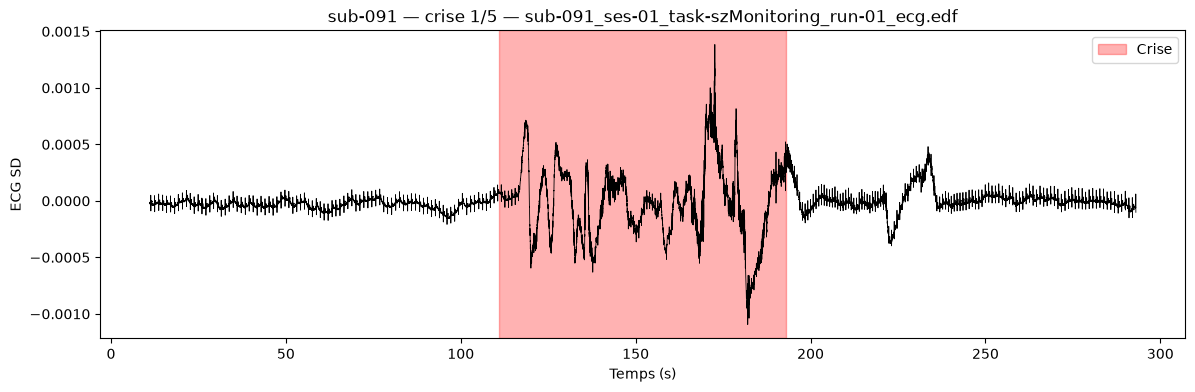

Reading 0 ... 61952  =      0.000 ...   242.000 secs...


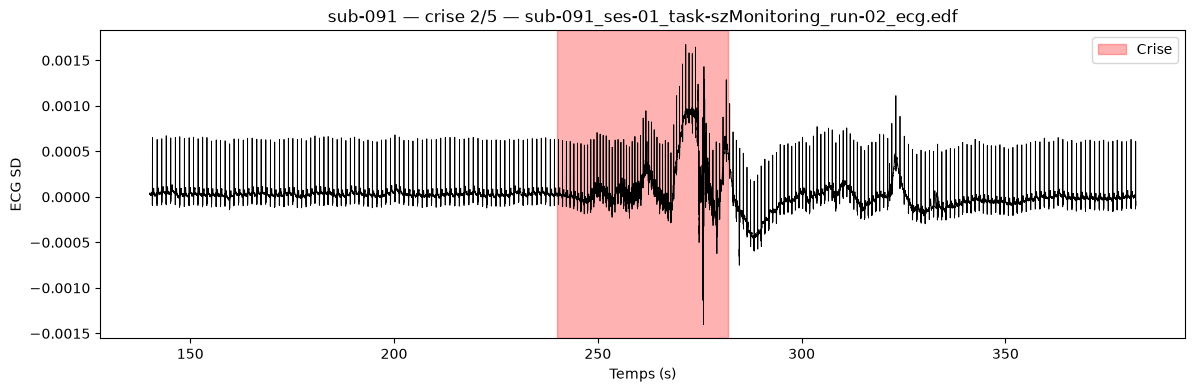

Reading 0 ... 84736  =      0.000 ...   331.000 secs...


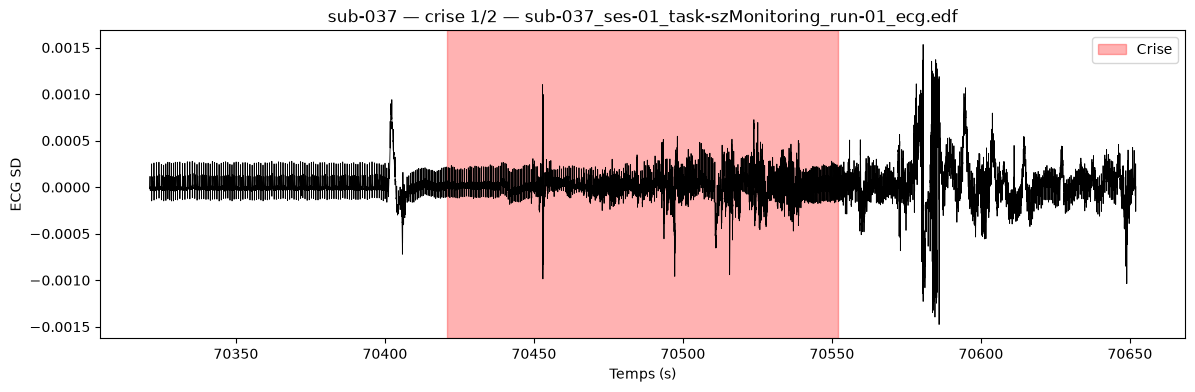

In [18]:
# Voir toutes les crises d'un patient
crises = liste_crises("sub-091")
print(crises)

# Tracer la 1re crise
tracer_crise("sub-091", marge=100)

# Tracer la 2e crise (on compte à partir de 0)
tracer_crise("sub-091", numero=1, marge=100)

# Un autre patient, avec plus de marge
tracer_crise("sub-037", numero=0, marge=100)

## 3. Résumé

Après avoir exploré notre dataset en générale, nous allons préparer notre dataset pour le traitement au future.
On va donc calculer le pourcentage de temps en crise par session et par patient.

In [ ]:
# Liste de tous les patients
patients = sorted(os.path.basename(d) for d in glob.glob(os.path.join(DOSSIER_DATA, "sub-*")))


def resume_runs_patient(patient):
    """Crée un résumé de chaque run d'un patient."""

    # Tous les fichiers TSV (= description pour toutes les runs pour un patient)
    fichiers_tsv = sorted(glob.glob(os.path.join(dossier_eeg(patient), "*_events.tsv")))

    # Toutes les crises du patient
    crises_patient = liste_crises(patient)

    lignes = []
    for tsv in fichiers_tsv: 

        # Crises appartenant uniquement à cette run
        crises_run = crises_patient[crises_patient["fichier_tsv"] == tsv]

        # ECG correspondant à cette run
        ecg = fichier_ecg(tsv)

        # Durée de cette run (en secondes)
        duree_totale = duree_run(tsv)

        # Durée totale passée en crise
        duree_crises = crises_run["duree"].sum()

        # Pourcentage de temps en crise
        if duree_totale > 0:
            pct_crise = 100 * duree_crises / duree_totale
        else:
            pct_crise = np.nan

        # Types de crises
        types_crises = ", ".join(crises_run["type"].unique())

        lignes.append({
            "patient": patient,
            "run": os.path.basename(tsv).split("_run-")[1].split("_")[0],   # "01", "02", ...
            "duree_totale_s": duree_totale,
            "nb_crises": len(crises_run),
            "duree_crises_s": duree_crises,
            "pct_crise": pct_crise,
            "types_crises": types_crises,
            "ecg_present": os.path.exists(ecg),
        })

    return pd.DataFrame(lignes)


# ---------- Tableau par run, pour tous les patients ----------
recap_runs = pd.concat([resume_runs_patient(p) for p in patients], ignore_index=True)
print(recap_runs["duree_totale_s"].isna().sum(), "runs sans durée")
print((~recap_runs["ecg_present"]).sum(), "runs sans fichier ECG")

# ---------- Résumé par patient (= par session, car chaque patient n'a qu'une session ses-01) ----------
recap_patients = recap_runs.groupby("patient").agg(
    nb_runs=("run", "count"),
    duree_totale_s=("duree_totale_s", "sum"),
    nb_crises=("nb_crises", "sum"),
    duree_crises_s=("duree_crises_s", "sum"),
)
recap_patients["duree_totale_h"] = recap_patients["duree_totale_s"] / 3600    # plus parlant en heures
recap_patients["pct_crise"] = 100 * recap_patients["duree_crises_s"] / recap_patients["duree_totale_s"]

# ---------- Résumé global ----------
duree_totale_s = recap_runs["duree_totale_s"].sum()
duree_crises_s = recap_runs["duree_crises_s"].sum()
recap_global = pd.DataFrame({
    "indicateur": ["Nombre de patients", "Nombre de runs", "Durée totale (h)", "Nombre de crises",
                   "Durée totale des crises (h)", "% de temps en crise", "Patients sans crise"],
    "valeur": pd.Series([len(recap_patients),
                         len(recap_runs),
                         round(duree_totale_s / 3600, 1),
                         recap_runs["nb_crises"].sum(),
                         round(duree_crises_s / 3600, 2),
                         round(100 * duree_crises_s / duree_totale_s, 3),
                         (recap_patients["nb_crises"] == 0).sum()], dtype=object),
})
print(recap_global.to_string(index=False))

# ---------- Sauvegarde en Excel : un seul fichier, 3 onglets, dans le dossier Projet ----------
fichier_excel = os.path.join(os.path.dirname(DOSSIER_DATA), "recap_crises.xlsx")
with pd.ExcelWriter(fichier_excel) as excel:
    recap_global.to_excel(excel, sheet_name="Global", index=False)
    recap_patients.sort_values("pct_crise", ascending=False).round(3).to_excel(excel, sheet_name="Par patient")
    recap_runs.round(3).to_excel(excel, sheet_name="Par run", index=False)
print("Fichier Excel enregistré :", fichier_excel)

# Les 10 patients avec le plus de temps en crise
recap_patients.sort_values("pct_crise", ascending=False).head(10)

0 runs sans durée
46 runs sans fichier ECG
                 indicateur   valeur
         Nombre de patients      125
             Nombre de runs     2850
           Durée totale (h)  11626.2
           Nombre de crises      883
Durée totale des crises (h)    14.33
        % de temps en crise    0.123
        Patients sans crise        0
Fichier Excel enregistré : C:\Users\Alina\Desktop\AMU\DESU Data science\Projet\recap_crises.xlsx


,nb_runs,duree_totale_s,nb_crises,duree_crises_s,duree_totale_h,pct_crise
patient,,,,,,
sub-090,4,12780.0,4,1685.0,3.550000,13.184664
sub-091,5,3812.0,5,285.0,1.058889,7.476390
sub-087,25,74926.0,42,2617.0,20.812778,3.492780
sub-120,3,9009.0,10,118.0,2.502500,1.309801
sub-055,3,151971.0,8,1475.0,42.214167,0.970580
sub-060,4,174487.0,25,1279.0,48.468611,0.733006
sub-073,62,1010546.0,75,7260.0,280.707222,0.718424
sub-056,5,225839.0,13,1399.0,62.733056,0.619468
sub-094,49,157508.0,3,974.0,43.752222,0.618381


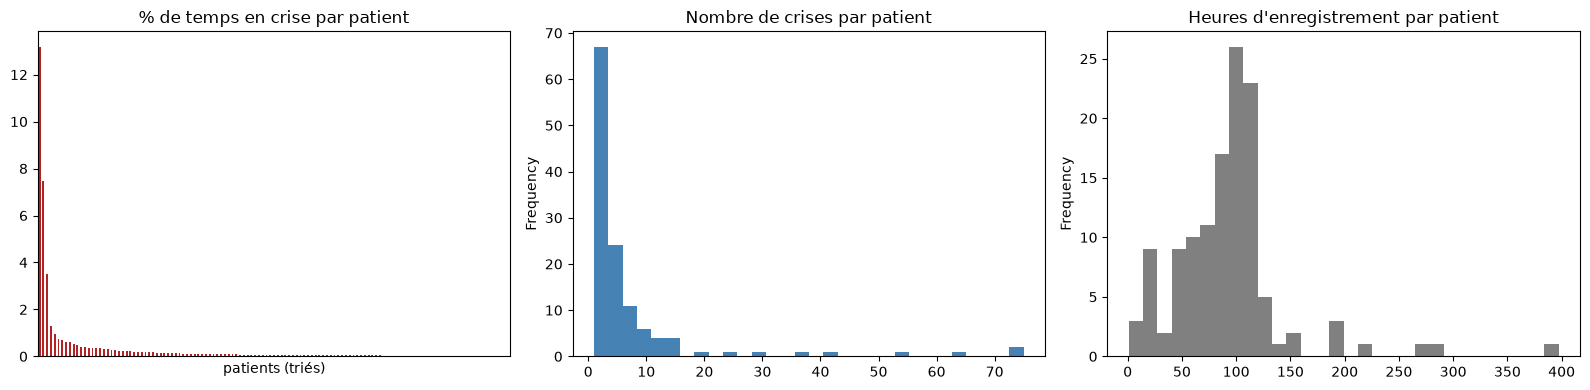

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
recap_patients["pct_crise"].sort_values(ascending=False).plot.bar(ax=axes[0], color="firebrick")
axes[0].set_title("% de temps en crise par patient")
axes[0].set_xticks([])
axes[0].set_xlabel("patients (triés)")
recap_patients["nb_crises"].plot.hist(ax=axes[1], bins=30, color="steelblue")
axes[1].set_title("Nombre de crises par patient")
recap_patients["duree_totale_h"].plot.hist(ax=axes[2], bins=30, color="grey")
axes[2].set_title("Heures d'enregistrement par patient")
plt.tight_layout()
plt.show()

## 4. Préparation des données : fenêtrage

Donc, maintenant, on va focaliser sur la préparation de la base des données pour l'entraînement du réseau des neurones et nos modèles.

Première étape est la découpage des données en fenêtres. Cela est fait parce que le signal ECG brut contient 250 valeurs par seconde, ce qui représente beaucoup trop de données pour être utilisé directement (le problème de la RAM) on le découpe donc en fenêtres de 10 secondes, et on résume chaque fenêtre par quelques mesures (comme la fréquence cardiaque), ce qui réduit fortement la taille des données tout en gardant l'information utile pour repérer une crise.

Ce fenêtrage est effectué run par run avant l'agrégation, afin de conserver l'alignement avec les annotations de chaque run, de limiter la mémoire utilisée, et d'éviter de créer des fenêtres ou des intervalles cardiaques artificiels à la jonction entre deux enregistrements.



### Description des features

Chaque ligne du tableau correspond à une fenêtre de 10 secondes. On détecte d'abord les battements du cœur (pics R),
puis on calcule les **intervalles RR** : le temps entre deux battements successifs, en millisecondes.
Les RR impossibles (< 300 ms ou > 2000 ms, c'est-à-dire plus de 200 ou moins de 30 battements/min) sont retirés.

| Feature | Définition | Calcul | Sur quelle durée |
|---|---|---|---|
| `fc` | Fréquence cardiaque moyenne (battements/min) | 60 000 / moyenne des RR (en ms) | les 10 s de la fenêtre |
| `nb_battements` | Nombre de battements détectés | on compte les pics R | les 10 s de la fenêtre |
| `delta_fc` | Accélération du cœur par rapport à son niveau habituel | fc actuelle − médiane de la fc des 30 fenêtres précédentes (5 min, au moins 3 min valides) | les 5 min précédentes |
| `sdnn` | Variabilité globale du rythme (ms) | écart-type des RR | la dernière minute |
| `rmssd` | Variabilité d'un battement au suivant (ms) | racine de la moyenne des (RR suivant − RR précédent)² | la dernière minute |
| `pnn50` | % de battements qui changent beaucoup (%) | % des différences entre RR successifs supérieures à 50 ms | la dernière minute |
| `lf` | Puissance des oscillations lentes du rythme (ms²), 0,04–0,15 Hz | spectre des RR (méthode de Welch), puissance dans la bande | les 2 min précédentes |
| `hf` | Puissance des oscillations rapides du rythme (ms²), 0,15–0,4 Hz, liées à la respiration | spectre des RR (méthode de Welch), puissance dans la bande | les 2 min précédentes |
| `lf_hf` | Rapport entre oscillations lentes et rapides, souvent interprété comme l'équilibre accélérateur / frein du cœur | lf / hf | les 2 min précédentes |
| `cible` | Ce qu'on veut prédire : fraction de la fenêtre en crise | temps en crise dans la fenêtre / 10 s (0 = pas de crise, 1 = crise pendant toute la fenêtre) | les 10 s de la fenêtre |

**Remarques :**
- Toutes les features regardent uniquement **le passé** et la fenêtre actuelle, jamais le futur (pas de leakage).
- La `cible` vient des annotations des médecins (`.tsv`) ; les features viennent uniquement du signal ECG.
- SDNN, RMSSD et pNN50 ont besoin de plus de battements qu'il n'y en a en 10 s, d'où un historique d'1 minute.
- LF et HF ont besoin de voir plusieurs oscillations lentes (jusqu'à 25 s chacune), d'où 2 minutes, le minimum habituel.
- Quand le signal est mauvais pendant 10 ou 20 s, on recopie la dernière valeur connue ; au-delà, la valeur reste vide (NaN).

In [ ]:
from scipy.signal import butter, sosfiltfilt, find_peaks, welch
# scipy.signal : pour filtrage, détection de pics et calcul du spectre de puissance
# scipy.signal.butter : pour créer un filtre passe-bande
# scipy.signal.sosfiltfilt : pour appliquer le filtre en avant et en arrière (filtrage sans décalage de phase)
# scipy.signal.find_peaks : pour détecter les pics R dans le signal ECG
# scipy.signal.welch : pour calculer le spectre de puissance d'un signal (méthode de Welch)

# Paramètres du fenêtrage
DUREE_FENETRE = 10        # secondes : une ligne du tableau = 10 s d'ECG
HISTORIQUE_VFC = 60       # secondes regardées en arrière pour SDNN, RMSSD, pNN50
HISTORIQUE_LF_HF = 120    # secondes regardées en arrière pour LF et HF (il faut au moins 2 min)
FS_RR = 4                 # Hz : on rééchantillonne les intervalles RR à 4 valeurs/s pour LF/HF


def detecter_battements(signal, fs):
    """Trouve les battements du cœur (pics R) et renvoie leurs temps en secondes."""
    # 1. Filtre 5-25 Hz : garde la forme des pics R, enlève la dérive lente et le bruit
    sos = butter(3, [5, 25], btype="bandpass", fs=fs, output="sos")
    filtre = sosfiltfilt(sos, signal)
    # 2. Dérivée au carré puis lissage : les pics R deviennent de grosses bosses positives
    energie = np.diff(filtre, prepend=filtre[0]) ** 2
    taille_lissage = max(1, int(0.12 * fs))
    energie = np.convolve(energie, np.ones(taille_lissage) / taille_lissage, mode="same")
    # 3. Recherche des pics, avec un seuil recalculé toutes les 60 s
    pics = []
    taille_bloc = int(60 * fs)
    for debut in range(0, len(energie), taille_bloc):
        bloc = energie[debut:debut + taille_bloc]
        if len(bloc) < fs:
            continue
        seuil = 0.3 * np.percentile(bloc, 99)
        p, _ = find_peaks(bloc, height=seuil, distance=int(0.33 * fs))   # au plus ~180 battements/min
        pics.append(p + debut)
    if len(pics) == 0:
        return np.array([])
    return np.concatenate(pics) / fs


def intervalles_rr(battements):
    """Temps entre deux battements (en ms), en enlevant les valeurs impossibles."""
    rr = np.diff(battements) * 1000          # en millisecondes
    temps_rr = battements[1:]                # moment où chaque intervalle se termine
    garder = (rr > 300) & (rr < 2000)        # entre 30 et 200 battements/min
    return temps_rr[garder], rr[garder]


def vfc_temporelle(rr):
    """SDNN, RMSSD, pNN50 à partir d'une liste d'intervalles RR (ms)."""
    if len(rr) < 3:
        return np.nan, np.nan, np.nan
    differences = np.diff(rr)
    sdnn = np.std(rr, ddof=1)                              # variabilité globale
    rmssd = np.sqrt(np.mean(differences ** 2))             # variabilité battement à battement
    pnn50 = 100 * np.mean(np.abs(differences) > 50)        # % de différences > 50 ms
    return sdnn, rmssd, pnn50


def vfc_frequentielle(temps_rr, rr, n_fenetres):
    """LF et HF (ms²) pour chaque fenêtre, calculés sur les 2 minutes qui précèdent sa fin."""
    lf = np.full(n_fenetres, np.nan)
    hf = np.full(n_fenetres, np.nan)
    if len(rr) < 10:
        return lf, hf
    # Les RR ne tombent pas à intervalles réguliers : on les rééchantillonne à 4 Hz
    t_regulier = np.arange(0, n_fenetres * DUREE_FENETRE, 1 / FS_RR)
    rr_regulier = np.interp(t_regulier, temps_rr, rr)
    # Pour chaque fenêtre : le morceau des 2 dernières minutes
    n_points = HISTORIQUE_LF_HF * FS_RR
    fins = np.arange(1, n_fenetres + 1) * DUREE_FENETRE * FS_RR
    debuts = fins - n_points
    possibles = np.where(debuts >= 0)[0]            # les 2 premières minutes n'ont pas assez d'historique
    if len(possibles) == 0:
        return lf, hf
    morceaux = rr_regulier[debuts[possibles][:, None] + np.arange(n_points)]
    morceaux = morceaux - morceaux.mean(axis=1, keepdims=True)
    # Spectre de chaque morceau (tous d'un coup), puis puissance dans chaque bande
    freqs, puissance = welch(morceaux, fs=FS_RR, nperseg=min(256, n_points), axis=-1)
    pas = freqs[1] - freqs[0]
    lf[possibles] = puissance[:, (freqs >= 0.04) & (freqs < 0.15)].sum(axis=1) * pas
    hf[possibles] = puissance[:, (freqs >= 0.15) & (freqs < 0.40)].sum(axis=1) * pas
    # Si trop peu de battements dans les 2 minutes, le calcul n'est pas fiable
    nb_rr = np.searchsorted(temps_rr, fins / FS_RR) - np.searchsorted(temps_rr, np.maximum(0, fins / FS_RR - HISTORIQUE_LF_HF))
    peu_fiable = nb_rr < 0.5 * HISTORIQUE_LF_HF         # moins de 30 battements/min en moyenne
    lf[peu_fiable] = np.nan
    hf[peu_fiable] = np.nan
    return lf, hf


def cible_par_fenetre(n_fenetres, crises_run):
    """Pour chaque fenêtre : la fraction de temps en crise (0 = pas de crise, 1 = crise pendant les 10 s)."""
    debut_fen = np.arange(n_fenetres) * DUREE_FENETRE
    fin_fen = debut_fen + DUREE_FENETRE
    temps_en_crise = np.zeros(n_fenetres)
    for _, crise in crises_run.iterrows():
        chevauchement = np.minimum(fin_fen, crise["debut"] + crise["duree"]) - np.maximum(debut_fen, crise["debut"])
        temps_en_crise += np.clip(chevauchement, 0, None)
    return np.clip(temps_en_crise / DUREE_FENETRE, 0, 1)


def features_run(tsv, crises_run):
    """Découpe l'ECG d'une run en fenêtres de 10 s et calcule les features + la cible."""
    chemin = fichier_ecg(tsv)
    if not os.path.exists(chemin):
        return pd.DataFrame()                                  # pas d'ECG pour cette run

    # 1. Charger toute la run (notre fonction charger_ecg, de 0 jusqu'à la fin)
    temps, signal, canal = charger_ecg(chemin, 0, np.inf)
    fs = round(1 / (temps[1] - temps[0]))                     # fréquence d'échantillonnage (250 Hz)
    signal = np.nan_to_num(signal)
    n_fenetres = len(signal) // int(DUREE_FENETRE * fs)
    if n_fenetres == 0:
        return pd.DataFrame()

    # 2. Battements et intervalles RR (on n'a plus besoin du signal brut ensuite)
    battements = detecter_battements(signal, fs)
    del signal, temps
    temps_rr, rr = intervalles_rr(battements)

    # 3. Features fenêtre par fenêtre
    lignes = []
    for k in range(n_fenetres):
        debut_fen = k * DUREE_FENETRE
        fin_fen = debut_fen + DUREE_FENETRE

        # Les INTERVALLES RR de la fenêtre (recherche dans temps_rr) -> pour la fc
        i_debut, i_fin = np.searchsorted(temps_rr, [debut_fen, fin_fen])
        rr_fenetre = rr[i_debut:i_fin]

        # Les BATTEMENTS de la fenêtre (recherche dans battements) -> pour nb_battements
        j_debut, j_fin = np.searchsorted(battements, [debut_fen, fin_fen])

        # Les intervalles RR de la DERNIÈRE MINUTE -> pour sdnn, rmssd, pnn50
        i_histo = np.searchsorted(temps_rr, fin_fen - HISTORIQUE_VFC)
        sdnn, rmssd, pnn50 = vfc_temporelle(rr[i_histo:i_fin])

        lignes.append({
            "debut_s": debut_fen,
            "fc": 60000 / rr_fenetre.mean() if len(rr_fenetre) >= 2 else np.nan,  # battements/min
            "nb_battements": j_fin - j_debut,
            "sdnn": sdnn,
            "rmssd": rmssd,
            "pnn50": pnn50,
        })
    df = pd.DataFrame(lignes)

    # 4. Fréquentiel : LF, HF, LF/HF (sur les 2 dernières minutes)
    df["lf"], df["hf"] = vfc_frequentielle(temps_rr, rr, n_fenetres)
    df["lf_hf"] = df["lf"] / df["hf"].where(df["hf"] > 0)

    # 5. delta_fc : fc actuelle moins la fc habituelle des 5 minutes précédentes (30 fenêtres)
    #    (au moins 18 fenêtres valides sur 30, soit 3 minutes, sinon NaN)
    fc_habituelle = df["fc"].rolling(30, min_periods=18).median().shift(1)
    df["delta_fc"] = df["fc"] - fc_habituelle

    # 6. Petits trous (signal mauvais pendant 10 ou 20 s) : on recopie la dernière valeur connue.
    #    On ne regarde que le passé (ffill) : jamais le futur, pour éviter le leakage.
    #    Les trous plus longs et le début de la run restent vides (NaN) : on les traitera à la normalisation.
    colonnes = ["fc", "sdnn", "rmssd", "pnn50", "lf", "hf", "lf_hf", "delta_fc"]
    df[colonnes] = df[colonnes].ffill(limit=2)

    # 7. La cible
    df["cible"] = cible_par_fenetre(n_fenetres, crises_run)
    df.insert(0, "run", os.path.basename(tsv).split("_run-")[1].split("_")[0])
    return df

Reading 0 ... 11717887  =      0.000 ... 45772.996 secs...


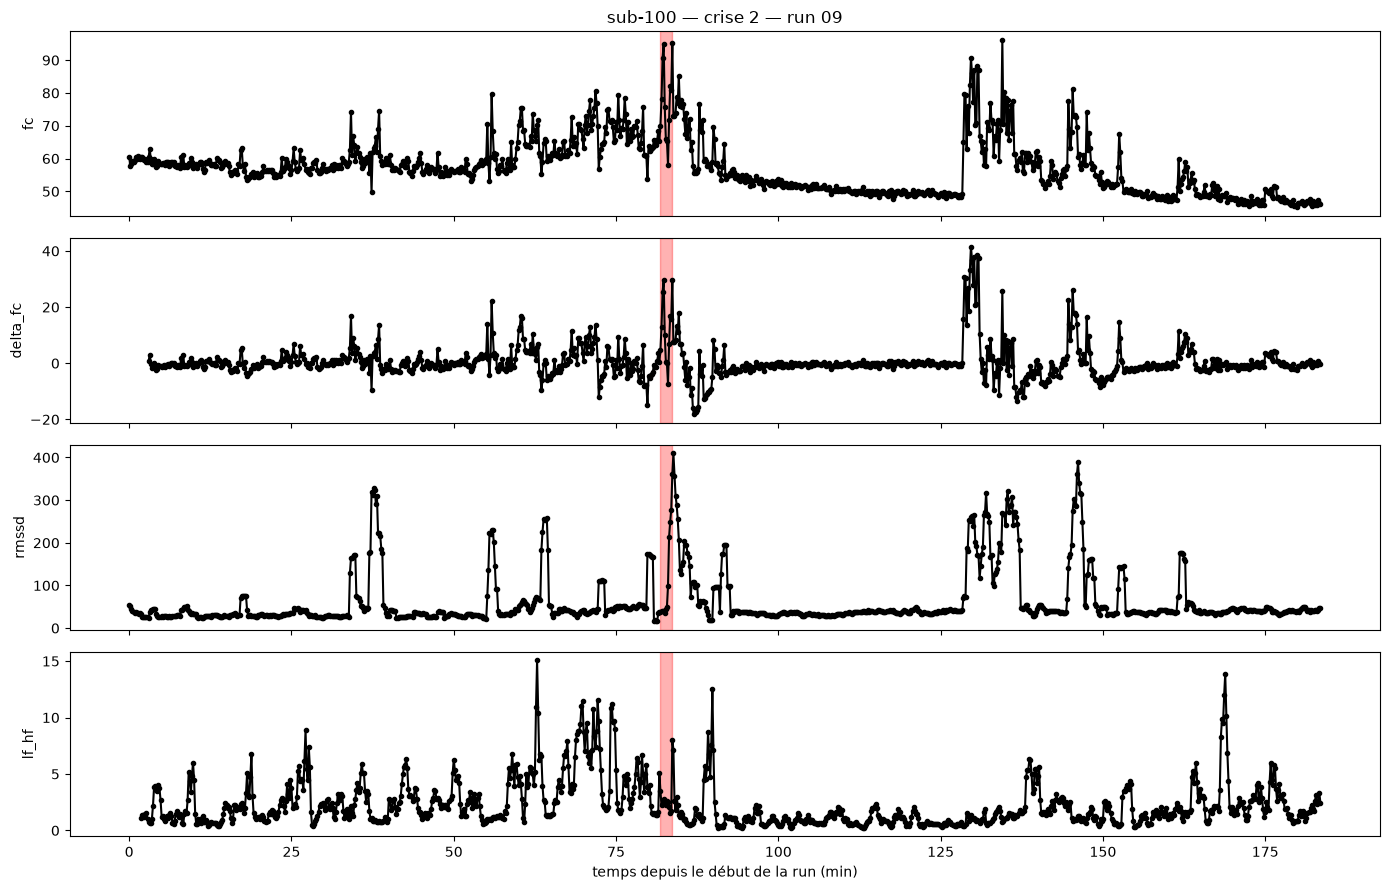

(4577, 12)


,run,debut_s,fc,nb_battements,sdnn,rmssd,pnn50,lf,hf,lf_hf,delta_fc,cible
0,09,0,60.631579,10,44.323460,54.320055,37.500000,NaN,NaN,NaN,NaN,0.0
1,09,10,57.722661,10,46.720551,51.764978,38.888889,NaN,NaN,NaN,NaN,0.0
2,09,20,58.314351,10,38.928051,43.903440,25.000000,NaN,NaN,NaN,NaN,0.0
3,09,30,59.350850,10,34.542313,40.062248,18.421053,NaN,NaN,NaN,NaN,0.0
4,09,40,58.976109,9,31.661870,37.363309,14.893617,NaN,NaN,NaN,NaN,0.0


In [39]:
def tracer_features_crise(patient, numero=0, marge_min=10):
    """Calcule les features de la run qui contient la crise, et les trace autour de la crise."""
    crises_patient = liste_crises(patient)
    crise = crises_patient.iloc[numero]
    tsv = crise["fichier_tsv"]
    crises_run = crises_patient[crises_patient["fichier_tsv"] == tsv]
    df = features_run(tsv, crises_run)
    if len(df) == 0:
        print("Pas d'ECG pour cette run")
        return df

    # On garde seulement +/- marge_min minutes autour de la crise
    zoom = df[(df["debut_s"] > crise["debut"] - marge_min * 60) &
              (df["debut_s"] < crise["debut"] + crise["duree"] + marge_min * 60)]
    temps_min = zoom["debut_s"] / 60

    colonnes = ["fc", "delta_fc", "rmssd", "lf_hf"]
    fig, axes = plt.subplots(len(colonnes), 1, figsize=(14, 9), sharex=True)
    for ax, col in zip(axes, colonnes):
        ax.plot(temps_min, zoom[col], color="black", marker=".")
        ax.axvspan(crise["debut"] / 60, (crise["debut"] + crise["duree"]) / 60, color="red", alpha=0.3)
        ax.set_ylabel(col)
    axes[0].set_title(f"{patient} — crise {numero + 1} — run {df['run'].iloc[0]}")
    axes[-1].set_xlabel("temps depuis le début de la run (min)")
    plt.tight_layout()
    plt.show()
    return df


df_test = tracer_features_crise("sub-100", numero=1, marge_min=100)
print(df_test.shape)
df_test.head()